In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

## Loading the dataset

In [2]:
# creating database connection 
conn = sqlite3.connect('inventory.db')

# fetching vendor summary data 
df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,271141.0,9737655.59,1259453.56,498191.89,68601.68,5926403.99,60.860686,1.868907,2.554976
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,307907.0,9264059.85,1055531.46,565750.57,144929.24,5460018.63,58.937644,1.877047,2.435321
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,358774.0,8681232.26,858557.25,659218.07,123780.22,5262928.58,60.624211,1.914411,2.539632
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,374520.0,8373427.80,783018.92,688154.04,257032.07,5112229.86,61.053012,1.856983,2.567593
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,255759.0,7966624.41,1022443.46,469930.06,257032.07,4943418.40,62.051606,1.851863,2.635158


## Exploratory Data Analysis
* Previously, we examned the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.
* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [3]:
# summary statistics 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10694.0,1.065066e+04,18751.963540,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10694.0,1.803979e+04,12662.892539,58.00,5790.500000,18761.500000,25514.750000,9.063100e+04
PurchasePrice,10694.0,2.438198e+01,109.259425,0.36,6.840000,10.450000,19.470000,5.681810e+03
ActualPrice,10694.0,3.563887e+01,148.232567,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10694.0,8.473774e+02,664.292772,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10694.0,3.145800e+03,11100.051710,1.00,36.000000,262.000000,1979.500000,3.376600e+05
TotalPurchaseDollars,10694.0,3.013712e+04,123076.599444,0.71,453.772500,3659.650000,20754.692500,3.811252e+06
TotalSalesQuantity,10694.0,5.844180e+03,20794.676455,0.00,61.000000,481.000000,3657.750000,6.296780e+05
TotalSalesDollars,10694.0,8.029676e+04,319695.636952,0.00,1363.145000,9872.530000,53850.760000,9.737656e+06
TotalSalesPrice,10694.0,3.556078e+04,84872.425779,0.00,549.757500,5394.780000,30296.425000,1.259454e+06


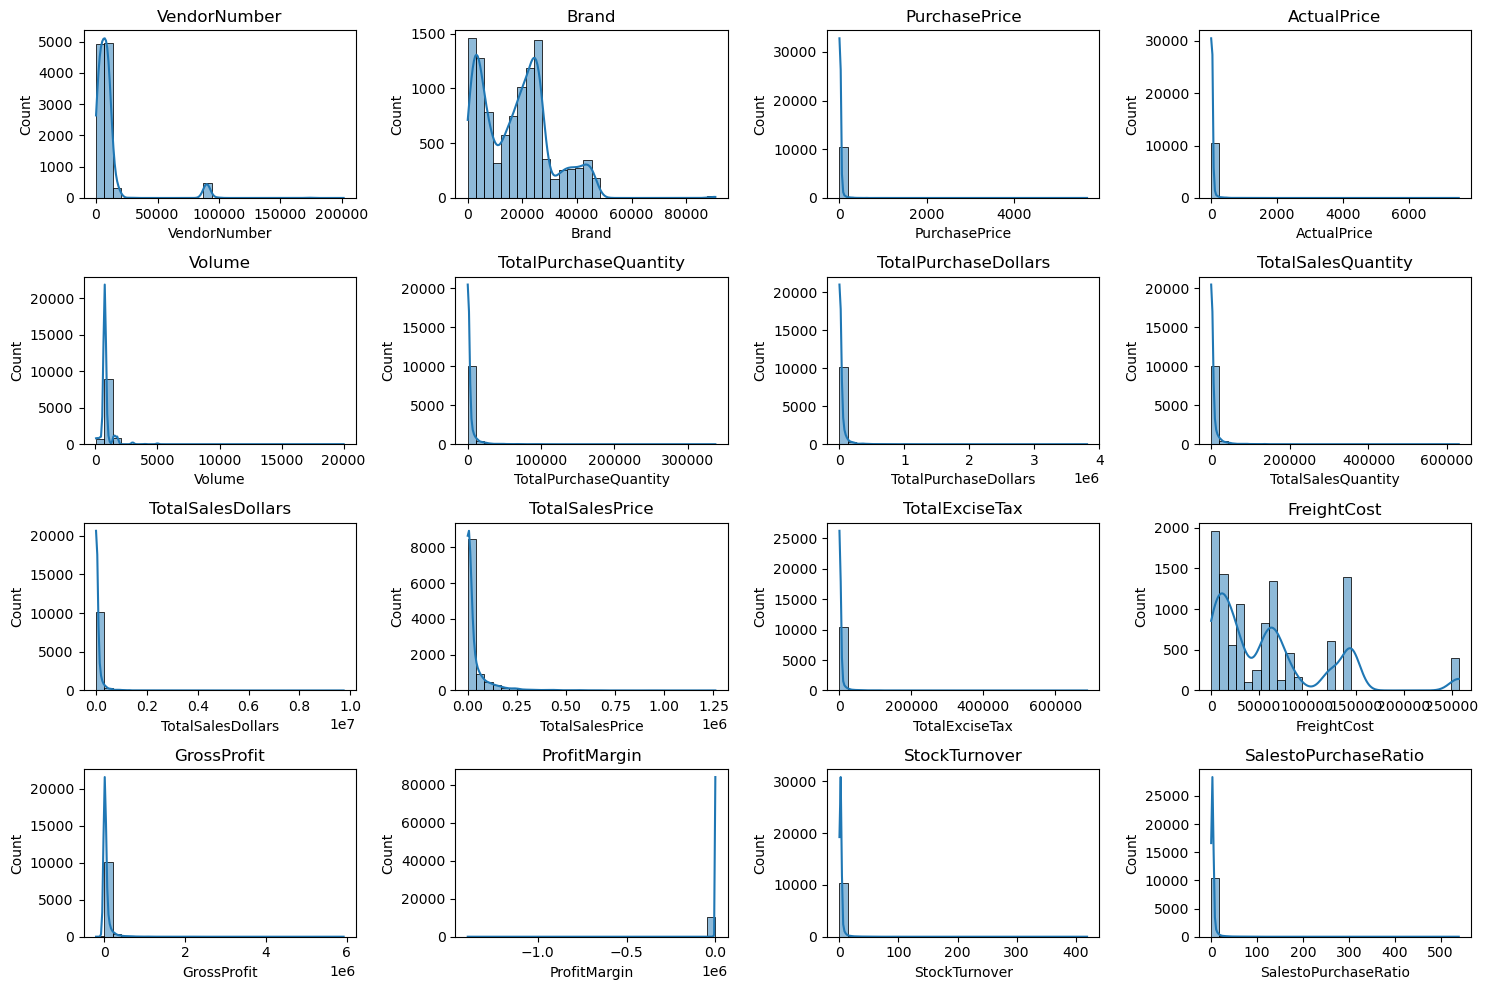

In [4]:
# Distribution Plots for Numerical Columns 
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

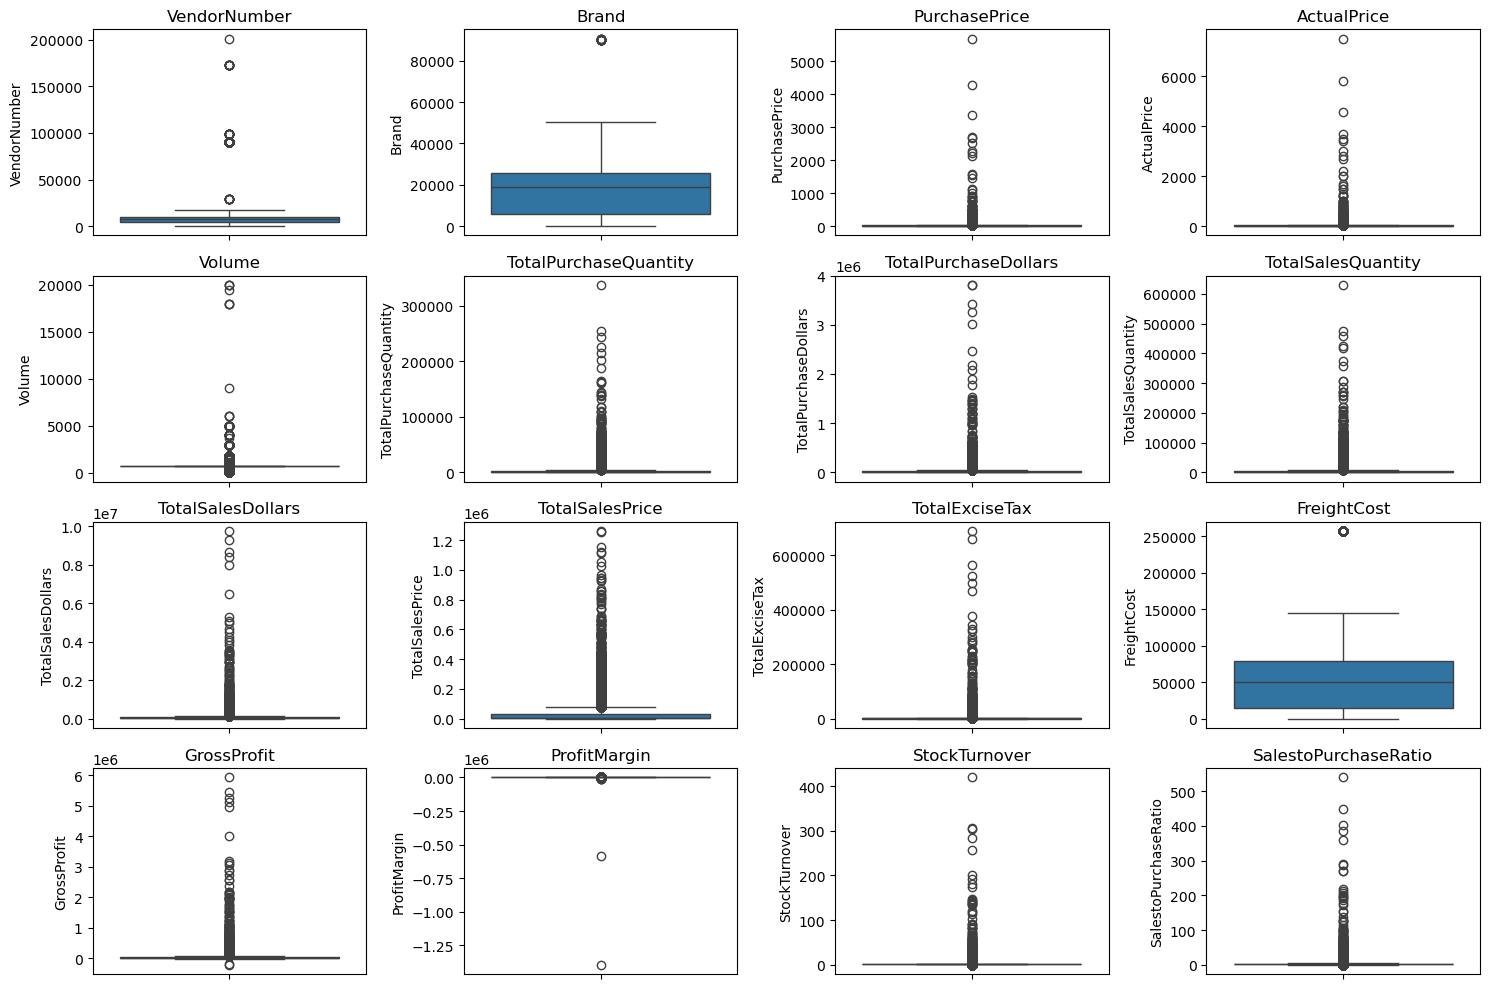

In [5]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Summary Statistics insights:
#### Negative & zero values:
* Gross Profit: Minimum value is -52,0002.78, including losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
* Profit Margin: Has a minimum of -(\infty \), which suggests cases where revenue is zero or even lower than costs.
* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

#### Outliers Indicated by High Standard Deviations:
* Purchase & Actual Prices: The max values (5,681,81 & 7,499,99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
* Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Values more then 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilling from older stock. 

In [6]:
# let's filter the data by removing inconsistencies 
df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", conn)

In [7]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,271141.0,9737655.59,1259453.56,498191.89,68601.68,5926403.99,60.860686,1.868907,2.554976
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,307907.0,9264059.85,1055531.46,565750.57,144929.24,5460018.63,58.937644,1.877047,2.435321
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,358774.0,8681232.26,858557.25,659218.07,123780.22,5262928.58,60.624211,1.914411,2.539632
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,374520.0,8373427.80,783018.92,688154.04,257032.07,5112229.86,61.053012,1.856983,2.567593
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,255759.0,7966624.41,1022443.46,469930.06,257032.07,4943418.40,62.051606,1.851863,2.635158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9788,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,7.0,25.93,15.95,0.77,27100.41,23.29,89.818743,3.500000,9.821970
9789,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,140.0,68.60,1.96,7.36,50293.62,66.26,96.588921,23.333333,29.316239
9790,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,4.0,3.96,1.98,0.20,14069.87,2.48,62.626263,2.000000,2.675676
9791,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,138.0,274.62,147.26,28.98,257032.07,273.15,99.464715,138.000000,186.816327


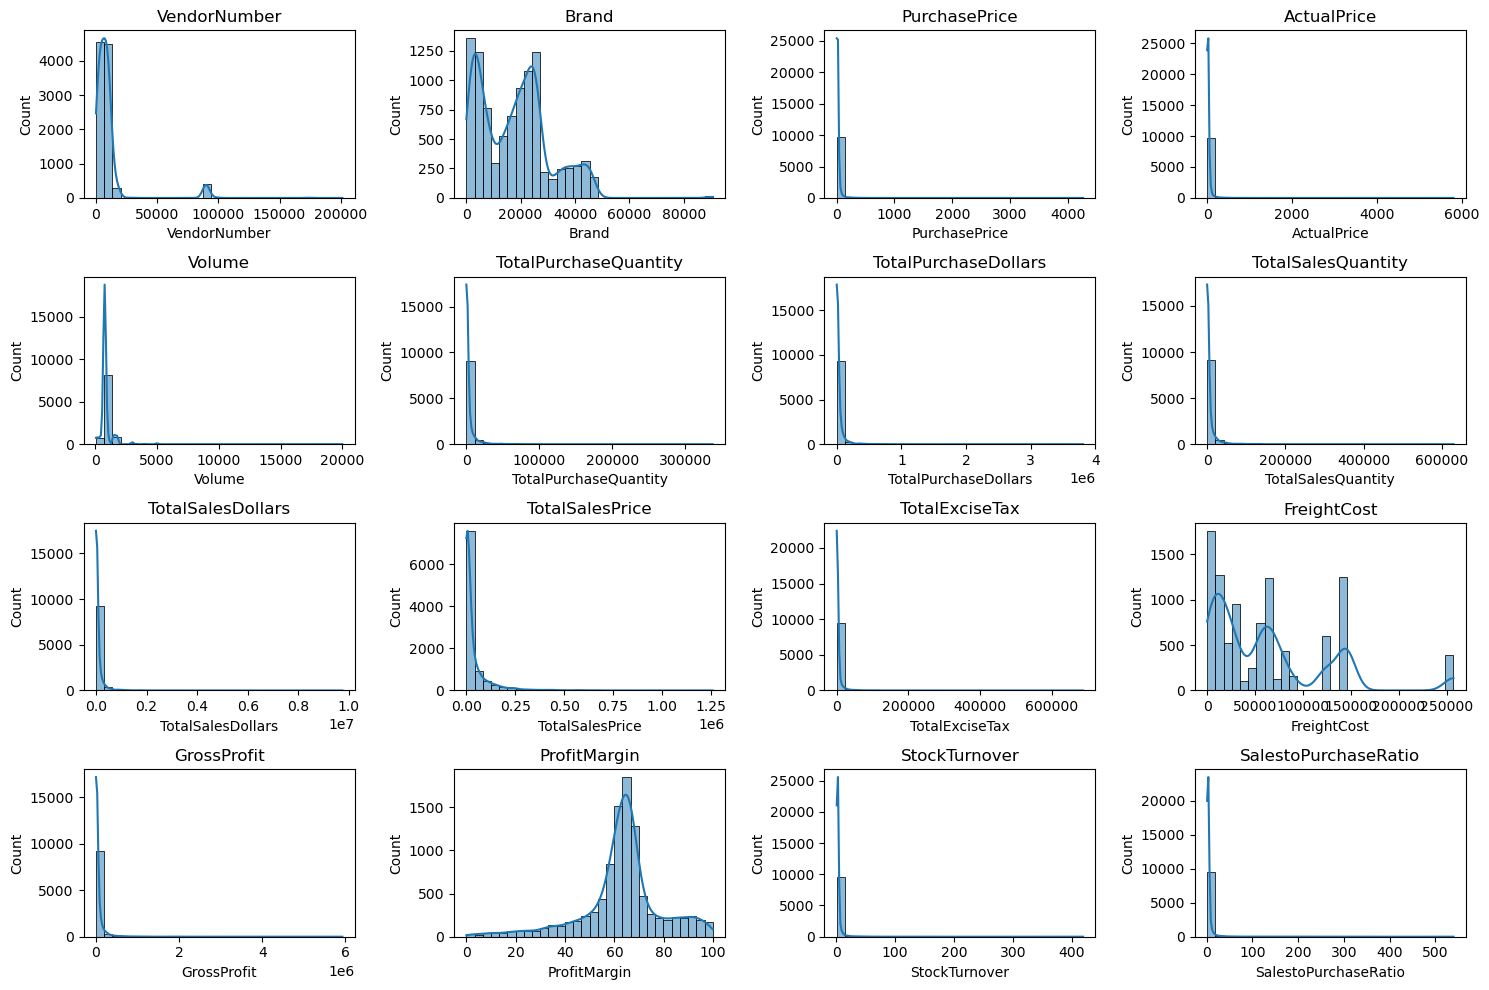

In [8]:
# Distribution Plots for Numerical Columns 
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

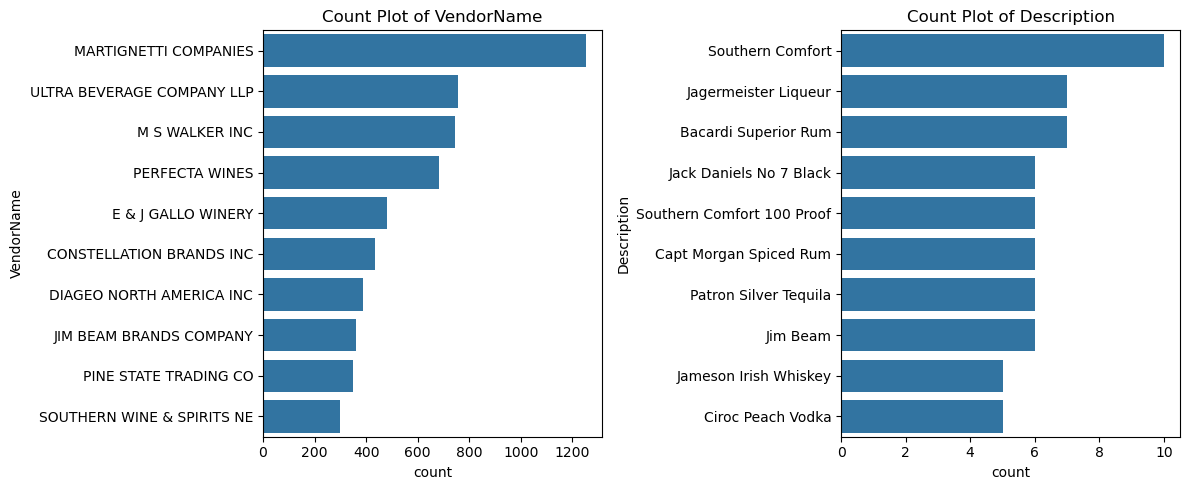

In [9]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

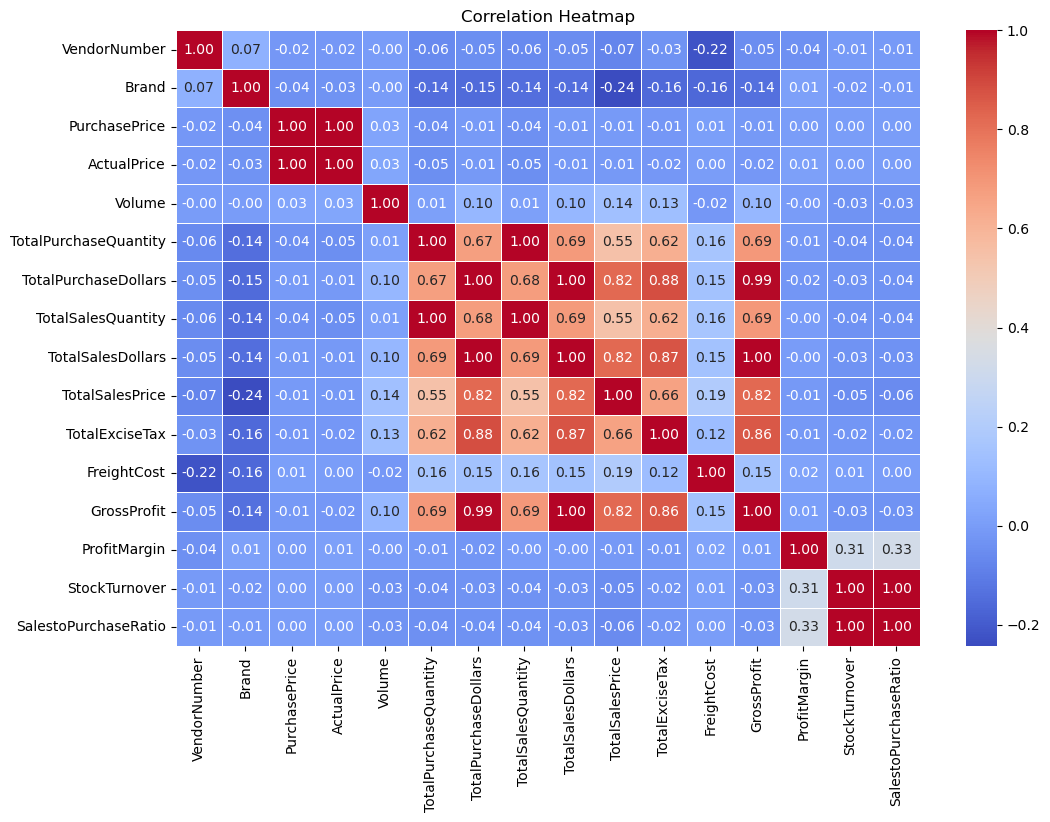

In [10]:
# Correlation Heatmap 
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Insights 
* Purchase has weak correlation with TotalSalesDollars (-0.01) and GrossProfit (-0.01), suggesting that price variation do not significantly impact sales revenue or profit.
* Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
* Negative correlation between profit margin & toal sales price (-0.179) suggests that as sales price increases, margin decrese, possibly due to competitive pricing presssures.
* StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability. 

### Data Analysis

#### Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.

In [11]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    "ProfitMargin":'mean'
}).reset_index()

In [12]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [13]:
low_sales_threshold

np.float64(883.1829999999998)

In [14]:
high_margin_threshold

np.float64(77.71245337493377)

In [15]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) & 
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins


,Description,TotalSalesDollars,ProfitMargin
7089,Santa Rita Organic Svgn Bl,19.98,83.233233
2344,Concannon Glen Ellen Wh Zin,25.93,89.818743
2473,Crown Royal Apple,31.84,91.080402
8206,Tracia Syrah,44.94,88.495772
7129,Sauza Sprklg Wild Berry Marg,55.92,91.076538
...,...,...,...
8081,Three Olives Whipped Cream,868.21,94.063648
5508,Merriam Cuvee Pnt Nr RRV,874.65,77.883725
2889,Donnafugata Mille una Notte,875.88,88.505275
2115,Chi Chi's Chocolate Malt RTD,879.20,99.008189


In [16]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']< 10000] # for better visualization

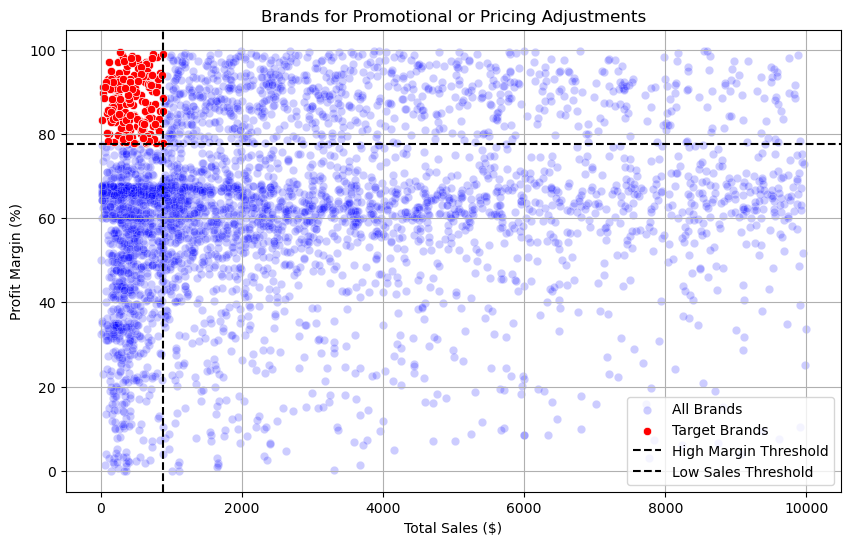

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

#### Which vendors and brands demonstrate the highest sales performance?

In [18]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [19]:
# Top Vendors & Brands by Sales Performance 
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      1.308812e+08
MARTIGNETTI COMPANIES         7.760819e+07
PERNOD RICARD USA             6.155500e+07
JIM BEAM BRANDS COMPANY       6.031030e+07
BACARDI USA INC               4.779125e+07
CONSTELLATION BRANDS INC      4.648835e+07
BROWN-FORMAN CORP             3.509295e+07
E & J GALLO WINERY            3.507188e+07
ULTRA BEVERAGE COMPANY LLP    3.353290e+07
M S WALKER INC                2.904774e+07
Name: TotalSalesDollars, dtype: float64

In [20]:
top_brands

Description
Jack Daniels No 7 Black    15173929.82
Tito's Handmade Vodka      14229817.60
Grey Goose Vodka           13895432.86
Capt Morgan Spiced Rum     11927856.21
Absolut 80 Proof           11920539.54
Jameson Irish Whiskey      10900647.88
Ketel One Vodka             9582599.31
Baileys Irish Cream         7870968.90
Kahlua                      6817036.11
Tanqueray                   6632488.02
Name: TotalSalesDollars, dtype: float64

In [21]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    15.17M
Tito's Handmade Vodka      14.23M
Grey Goose Vodka           13.90M
Capt Morgan Spiced Rum     11.93M
Absolut 80 Proof           11.92M
Jameson Irish Whiskey      10.90M
Ketel One Vodka             9.58M
Baileys Irish Cream         7.87M
Kahlua                      6.82M
Tanqueray                   6.63M
Name: TotalSalesDollars, dtype: object

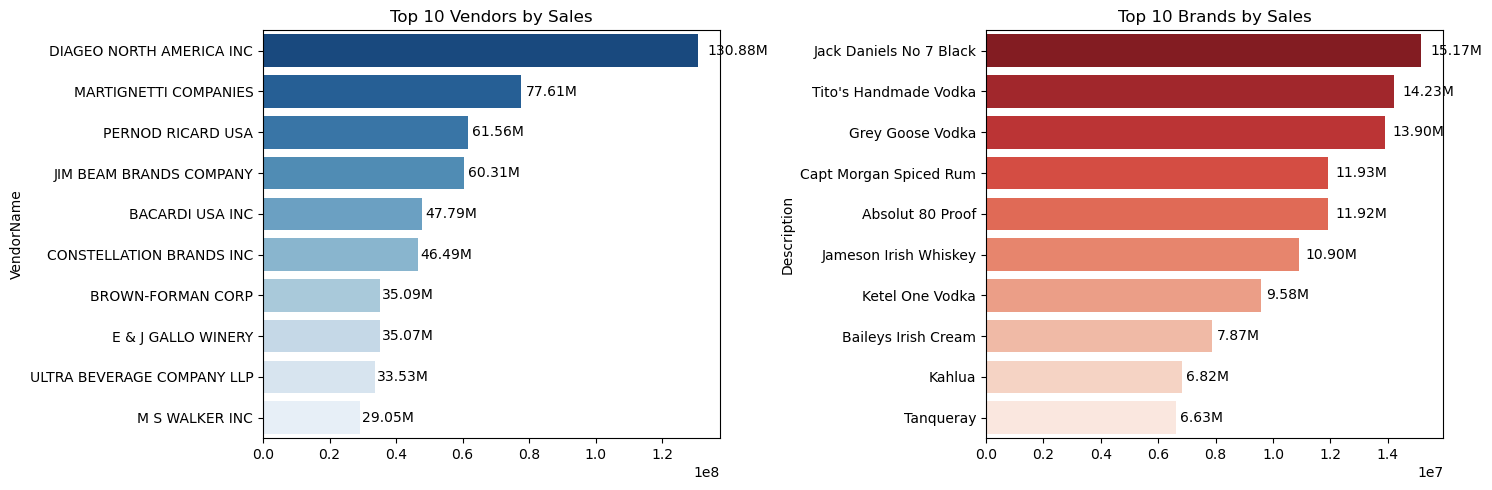

In [22]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors 
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands 
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

### Which Vendors contribute the most to total purchase dollars?

In [23]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()

In [24]:
vendor_performance['Purchase_Contribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()*100

In [25]:
vendor_performance = round(vendor_performance.sort_values('Purchase_Contribution%', ascending=False), 2)

In [26]:
# Display Top 10 Vendors 
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_Contribution%
26,DIAGEO NORTH AMERICA INC,50.89M,79.99M,130.88M,15.96
59,MARTIGNETTI COMPANIES,27.35M,50.26M,77.61M,8.58
70,PERNOD RICARD USA,24.10M,37.45M,61.56M,7.56
48,JIM BEAM BRANDS COMPANY,24.05M,36.26M,60.31M,7.54
7,BACARDI USA INC,17.61M,30.18M,47.79M,5.52
21,CONSTELLATION BRANDS INC,15.55M,30.94M,46.49M,4.88
12,BROWN-FORMAN CORP,13.50M,21.59M,35.09M,4.23
109,ULTRA BEVERAGE COMPANY LLP,12.65M,20.89M,33.53M,3.97
31,E & J GALLO WINERY,12.25M,22.82M,35.07M,3.84
55,M S WALKER INC,10.56M,18.49M,29.05M,3.31


In [27]:
top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_Contribution%,Cumulative_Contribution%
26,DIAGEO NORTH AMERICA INC,50.89M,79.99M,130.88M,15.96,15.96
59,MARTIGNETTI COMPANIES,27.35M,50.26M,77.61M,8.58,24.54
70,PERNOD RICARD USA,24.10M,37.45M,61.56M,7.56,32.10
48,JIM BEAM BRANDS COMPANY,24.05M,36.26M,60.31M,7.54,39.64
7,BACARDI USA INC,17.61M,30.18M,47.79M,5.52,45.16
21,CONSTELLATION BRANDS INC,15.55M,30.94M,46.49M,4.88,50.04
12,BROWN-FORMAN CORP,13.50M,21.59M,35.09M,4.23,54.27
109,ULTRA BEVERAGE COMPANY LLP,12.65M,20.89M,33.53M,3.97,58.24
31,E & J GALLO WINERY,12.25M,22.82M,35.07M,3.84,62.08
55,M S WALKER INC,10.56M,18.49M,29.05M,3.31,65.39


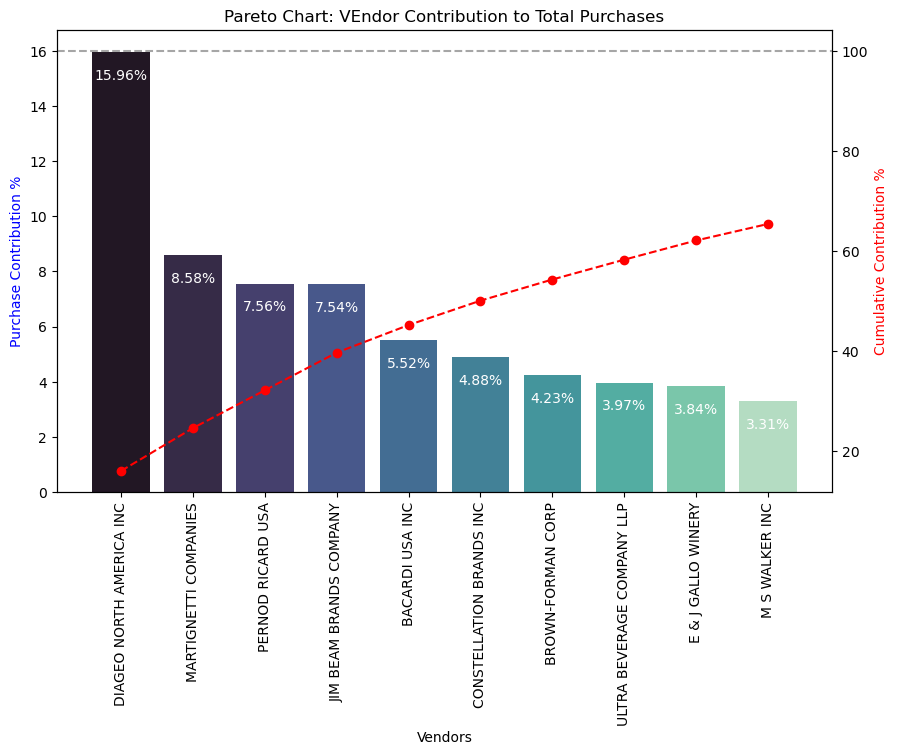

In [28]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution% 
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['Purchase_Contribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value - 1, str(value) +'%', ha='center', fontsize = 10, color='White')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative Contribution')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: VEndor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

plt.show()

#### How much of total procurement is dependent on the top vendors?

In [29]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['Purchase_Contribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.39 %


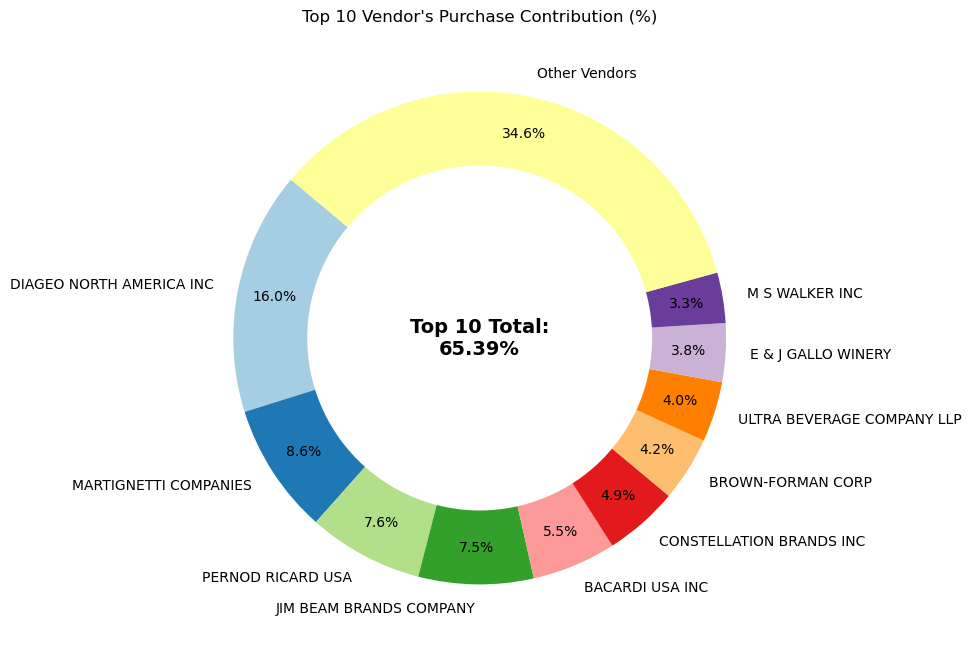

In [30]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['Purchase_Contribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution 

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart 
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a 'donut' effect 
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

#### Does purchasing in bulk reduce the unit price, and what is the optimal purchase volumne for cost savings?

In [31]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [32]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['Small', 'Medium', 'Large'])

In [33]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.549899
Medium,16.774885
Large,11.099406


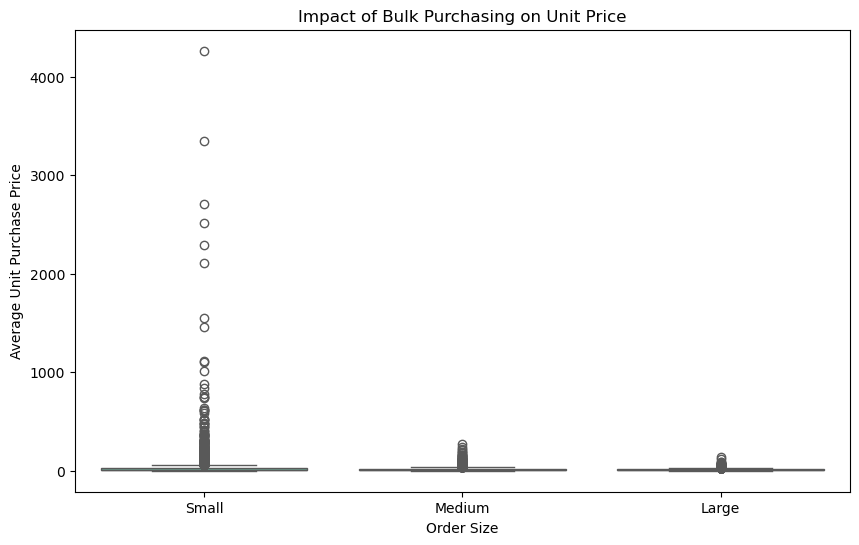

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='OrderSize', y='UnitPurchasePrice', palette='Set2')
plt.title('Impact of Bulk Purchasing on Unit Price')
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

* Vendors buying in bulk (Large Order Size) get the lowest unit pric ($10.78 per unit), ,eaning higher margins if they can manage inventory efficiently.
* The price difference between Small and Large orders is substantial (-72% reduction in unit cost)
* This suggests that bulk pricing strategies successfully encourage vendors to purchase is larger volumes, leading to higher overall sales despite lower per-unit revenue. 

#### Which Vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [35]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True).head(10)

,StockTurnover
VendorName,
SURVILLE ENTERPRISES CORP,0.666667
UNCORKED,0.718750
THE PIERPONT GROUP LLC,0.722222
Dunn Wine Brokers,0.730769
MOET HENNESSY USA INC,0.750000
VRANKEN AMERICA,0.757962
APPOLO VINEYARDS LLC,0.758333
REMY COINTREAU USA INC,0.764268
PERNOD RICARD USA,0.765112


#### How much capital is locked in unused inventory per vendor, and which vendors contribute the most to it?

In [36]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]).clip(lower=0) * df["PurchasePrice"]
print("Total Unsold Capital:", format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital: 221.26K


In [37]:
# Aggregate Capital Locked per vendor 
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital 
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
59,MARTIGNETTI COMPANIES,53.69K
109,ULTRA BEVERAGE COMPANY LLP,33.53K
69,PERFECTA WINES,29.64K
48,JIM BEAM BRANDS COMPANY,12.28K
55,M S WALKER INC,12.13K
38,FREDERICK WILDMAN & SONS,10.93K
72,PINE STATE TRADING CO,8.69K
90,SOUTHERN WINE & SPIRITS NE,4.60K
83,SEA BREEZE CELLARS LLC,4.41K
21,CONSTELLATION BRANDS INC,4.26K


#### What is the 95% cofidence intervals for profit margins of top-performing vendors.

In [38]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

In [39]:
top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

In [40]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (62.95, 63.46), Mean: 63.21
Low Vendors 95% CI: (59.31, 60.95), Mean: 60.13


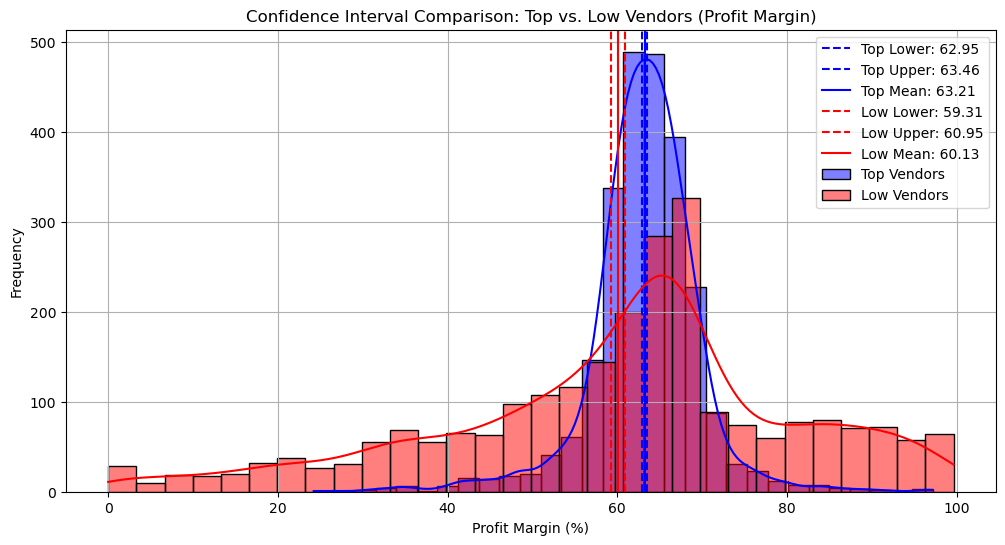

In [41]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot 
sns.histplot(top_vendors, kde=True, color='blue', bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color='blue', linestyle='--', label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color='blue', linestyle='--', label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color='blue', linestyle='-', label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot 
sns.histplot(low_vendors, kde=True, color='red', bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color='red', linestyle='--', label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color='red', linestyle='--', label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color='red', linestyle='-', label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot 
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

* The confidence interval for low-performing vendors (59.31% to 60.95%) is significantly higher than that of top-performing vendors (62.95% to 63.46%).
* This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
* For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
* For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

#### Is there a significant difference in profit margins between top_performing and low_performing vendors?
Hypothesis:
* Ho (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-perforing vendors.
* Ha (Alternative Hypothesis): The mean profit margins of top-performing and low_performing are significantly different.

In [42]:
top_threshold= df ["TotalSalesDollars"].quantile(0.75)
low_threshold= df ["TotalSalesDollars"].quantile(0.25)

top_vendors= df [df ["TotalSalesDollars"] >= top_threshold] ["ProfitMargin"].dropna()
low_vendors= df [df ["TotalSalesDollars"] <= low_threshold] ["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

#Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject Ha: No significant difference in profit margins.")

T-Statistic: 7.0043, P-Value: 0.0000
Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.


In [50]:
brand_performance.to_csv('clean_data/BrandPerformance.csv', index=False)
low_vendors.to_csv('clean_data/LowTurnoverVendor.csv', index=False)
df.to_csv('clean_data/vendor_sales_summary.csv', index=False)